**Importing Necessory Libraries**

In [ ]:
!pip install pandas scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**Mounting with Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/DS_H_Features Face_Parts/DS_H_Features LowerFace(HS).csv'
df = pd.read_csv(file_path)

In [ ]:
df.head()

,image_name,0,1,2,3,4,5,6,7,8,...,2039,2040,2041,2042,2043,2044,2045,2046,2047,DownSyndromeStatus
0,LowerFace(HS)_down_592.jpg,0.652509,0.013617,0.202391,2.992451,0.690517,0.012656,0.692469,0.199264,0.041282,...,0.098512,1.210918,0.890957,0.061048,0.000000,0.070555,0.459846,0.174955,0.000000,1
1,LowerFace(HS)_down_543.jpg,0.419749,0.150766,0.000000,2.232147,1.558530,0.663418,0.297999,0.803678,0.002620,...,0.451862,2.067907,2.462290,0.035911,0.000000,0.122912,0.169483,0.055889,0.012156,1
2,LowerFace(HS)_down_588.jpg,0.001396,0.000000,0.069495,3.830718,1.843658,0.034239,1.785019,0.386588,0.000000,...,0.266912,0.389073,1.163681,0.042391,0.000000,0.000547,0.197407,0.013417,0.135957,1
3,LowerFace(HS)_down_545.jpg,0.066989,0.004261,0.007000,3.640053,2.338083,0.000000,0.204635,0.634193,0.113476,...,0.877511,0.673969,0.794076,0.205203,0.000000,0.000000,0.041912,0.349179,0.041686,1
4,LowerFace(HS)_down_601.jpg,0.613894,0.119181,0.000000,5.501335,0.639455,0.049316,0.298649,0.046304,0.050925,...,0.141637,0.601987,0.686965,0.154828,0.004169,0.250151,0.196305,0.102043,0.271524,1


In [ ]:
#checking for null values
df.isnull().sum()

,0
image_name,0
0,0
1,0
2,0
3,0
...,...
2044,0
2045,0
2046,0
2047,0


In [ ]:
#null value count
df.isnull().sum().sum()

0

In [ ]:
#Dropping the target coloumn (DownSyndromeStatus) and 'image_name' column as it's not relevant for prediction
X=df.drop(['DownSyndromeStatus','image_name'],axis=1)
y=df['DownSyndromeStatus']

In [ ]:
#Spliting the data with 80:20 ratio
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [ ]:
#Initializing the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

#Fitting the model on the training data
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
#Prediction on the test set
y_pred = rf_model.predict(X_test)

#Calculating accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

#Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(conf_matrix)

#Classification report
class_report = classification_report(y_test, y_pred)
print('Classification Report:')
print(class_report)

Accuracy: 0.74
Confusion Matrix:
[[205  87]
 [ 68 234]]
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.70      0.73       292
           1       0.73      0.77      0.75       302

    accuracy                           0.74       594
   macro avg       0.74      0.74      0.74       594
weighted avg       0.74      0.74      0.74       594



**Confusion Matrix**

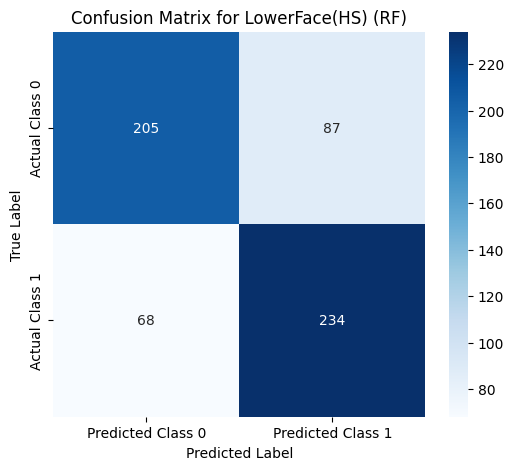

In [ ]:
#Creating heatmap for confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Class 0', 'Predicted Class 1'],
            yticklabels=['Actual Class 0', 'Actual Class 1'])

#giving labels, title, and displaying the plot
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for LowerFace(HS) (RF)')
plt.show()

**Area Under the Curve Score**

In [ ]:
#Getting predicted probabilities for the positive class
y_pred_prob = rf_model.predict_proba(X_test)[:, 1]

#Calculating False Positive Rate, True Positive Rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

#Calculating the AUC score
auc_score = roc_auc_score(y_test, y_pred_prob)
print(f'AUC Score: {auc_score:.2f}')

AUC Score: 0.83


**ROC (Receiver Operating Characteristic) Curve**

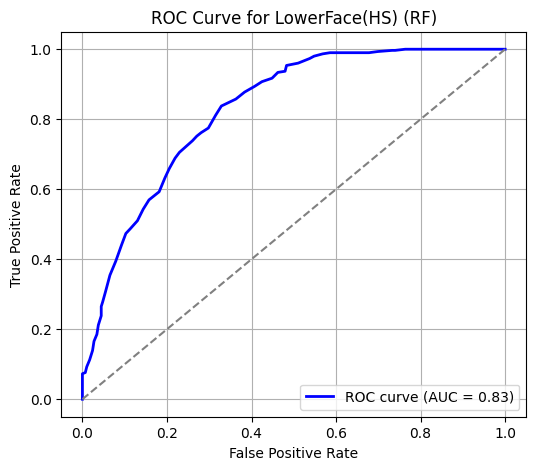

In [ ]:
#Plotting the ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

#Adding labels, title, and legend
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for LowerFace(HS) (RF)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()